# 02 — MLP Multi-class Classifier (no resampling)

**Strategy.** No GAN. No undersampling. We let the *loss function* — not the
data distribution — handle the class imbalance:

1. **Class weights** (default) — `sklearn`-balanced weights, passed to
   `model.fit(class_weight=...)`. Errors on rare classes get scaled up
   proportionally.
2. **Focal loss** (alternative) — flip `cfg.MLP_CONFIG["imbalance_strategy"]`
   to `"focal"` to use focal loss instead. Focal loss automatically
   down-weights easy (BENIGN) examples and focuses gradient on hard ones.

Both let the model see the **real** distribution while still learning
minorities. We track **macro-F1** (not accuracy) because accuracy is
dominated by BENIGN.


In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
)

from src import config as cfg
from src.models import build_mlp, compute_balanced_class_weights
sns.set_theme(style="whitegrid")
print("TF:", tf.__version__)
print("Imbalance strategy:", cfg.MLP_CONFIG["imbalance_strategy"])


TF: 2.21.0
Imbalance strategy: class_weights


## 1. Load data, scaler, label map

In [2]:
train = pd.read_csv(cfg.PROCESSED_DIR / "train.csv")
val   = pd.read_csv(cfg.PROCESSED_DIR / "val.csv")

scaler = joblib.load(cfg.SCALER_FILE)
with open(cfg.FEATURE_NAMES_FILE) as f: feature_names = json.load(f)
with open(cfg.LABEL_MAP_FILE)    as f: label_map = {int(k):v for k,v in json.load(f).items()}
inv_map = {v:k for k,v in label_map.items()}
class_names = [label_map[i] for i in range(len(label_map))]

# Some rows in val may carry rare labels we dropped at preprocessing.
train = train[train[cfg.LABEL_COL].isin(inv_map)].reset_index(drop=True)
val   = val[val[cfg.LABEL_COL].isin(inv_map)].reset_index(drop=True)

X_train = scaler.transform(train[feature_names].astype(np.float32).values)
y_train = train[cfg.LABEL_COL].map(inv_map).astype(int).values
X_val   = scaler.transform(val[feature_names].astype(np.float32).values)
y_val   = val[cfg.LABEL_COL].map(inv_map).astype(int).values

print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  classes: {len(label_map)}")


X_train: (1979465, 77)  X_val: (424171, 77)  classes: 12


## 2. Class distribution (kept untouched)

C:\Users\diable\AppData\Local\Temp\ipykernel_6412\1310868045.py:8: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
d:\smart_ids\ids_pfa\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


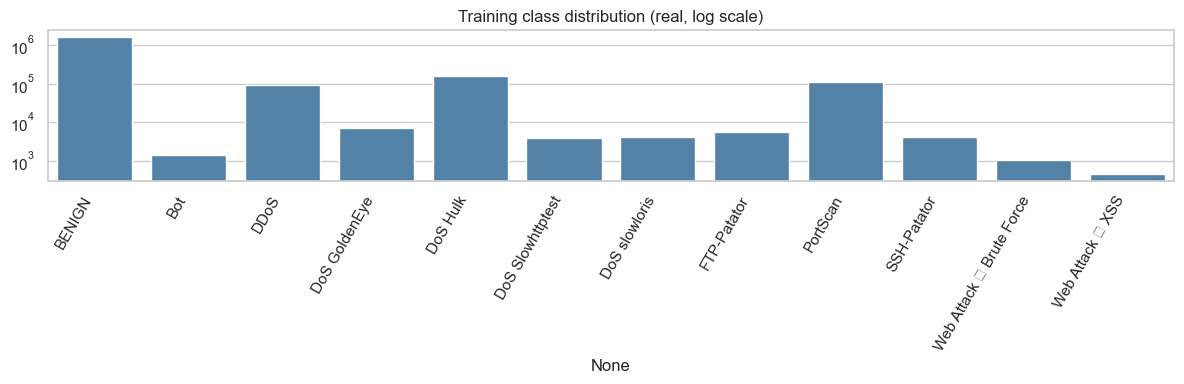

BENIGN                      1589924
Bot                            1369
DDoS                          89617
DoS GoldenEye                  7205
DoS Hulk                     161087
DoS Slowhttptest               3849
DoS slowloris                  4057
FTP-Patator                    5555
PortScan                     111163
SSH-Patator                    4128
Web Attack  Brute Force       1055
Web Attack  XSS                456
Name: count, dtype: int64


In [3]:
dist = pd.Series(y_train).value_counts().sort_index()
dist.index = [class_names[i] for i in dist.index]
plt.figure(figsize=(12, 4))
sns.barplot(x=dist.index, y=dist.values, color="steelblue")
plt.yscale("log")
plt.xticks(rotation=60, ha="right")
plt.title("Training class distribution (real, log scale)")
plt.tight_layout(); plt.show()
print(dist)


## 3. Compute class weights

`compute_class_weight('balanced', ...)` gives weight ∝ N / (n_classes * count_class).
We cap at `cfg.MLP_CONFIG['max_class_weight']` so the rarest classes don't
explode the gradient.


In [4]:
class_weights = compute_balanced_class_weights(
    y_train, max_weight=cfg.MLP_CONFIG["max_class_weight"]
)

cw_df = pd.DataFrame([
    {"class": class_names[i], "count": int((y_train == i).sum()), "weight": class_weights[i]}
    for i in sorted(class_weights)
]).sort_values("weight", ascending=False)
print(cw_df.to_string(index=False))


                   class   count    weight
                     Bot    1369 10.000000
           DoS GoldenEye    7205 10.000000
           DoS slowloris    4057 10.000000
        DoS Slowhttptest    3849 10.000000
        Web Attack  XSS     456 10.000000
Web Attack  Brute Force    1055 10.000000
             FTP-Patator    5555 10.000000
             SSH-Patator    4128 10.000000
                    DDoS   89617  1.840671
                PortScan  111163  1.483906
                DoS Hulk  161087  1.024014
                  BENIGN 1589924  0.103751


## 4. Build the MLP

In [5]:
strategy = cfg.MLP_CONFIG["imbalance_strategy"]
loss_kind = "focal" if strategy == "focal" else "sparse_categorical_crossentropy"

model = build_mlp(
    input_dim=X_train.shape[1],
    n_classes=len(label_map),
    hidden_units=cfg.MLP_CONFIG["hidden_units"],
    dropout=cfg.MLP_CONFIG["dropout"],
    learning_rate=cfg.MLP_CONFIG["learning_rate"],
    loss=loss_kind,
    focal_gamma=cfg.MLP_CONFIG["focal_gamma"],
    focal_alpha=cfg.MLP_CONFIG["focal_alpha"],
)
model.summary()


2026-05-10 00:37:36,971 [WARNING] tensorflow: TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


Model: "smarttids_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 77)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (Dense)                 │ (None, 512)            │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_0 (Dropout)                │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ probs (Dense)                   │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,292 (817.55 KB)

 Trainable params: 207,500 (810.55 KB)

 Non-trainable params: 1,792 (7.00 KB)

## 5. Macro-F1 callback (the metric that actually matters)

In [6]:
class MacroF1Callback(tf.keras.callbacks.Callback):
    """Compute macro-F1 on the validation set after each epoch."""
    def __init__(self, X, y):
        super().__init__()
        self.X, self.y = X, y
        self.history = []
    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.X, batch_size=4096, verbose=0).argmax(axis=1)
        score = f1_score(self.y, y_pred, average="macro", zero_division=0)
        logs = logs or {}
        logs["val_macro_f1"] = score
        self.history.append(score)
        print(f"  -> val_macro_f1: {score:.4f}")

f1_cb = MacroF1Callback(X_val, y_val)


## 6. Train

In [7]:
cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)

callbacks = [
    f1_cb,
    EarlyStopping(monitor="val_macro_f1", mode="max",
                  patience=cfg.MLP_CONFIG["patience"], restore_best_weights=True),
    # Monitor macro-F1 (max) instead of val_loss — with class weights the
    # weighted val_loss is a noisy proxy for actual classification quality.
    ReduceLROnPlateau(monitor="val_macro_f1", mode="max",
                      factor=0.5, patience=4, min_lr=1e-6),
    ModelCheckpoint(filepath=str(cfg.MLP_MODEL_FILE),
                    monitor="val_macro_f1", mode="max", save_best_only=True),
]

# class_weight is only used for the cross-entropy strategy.
fit_kwargs = {}
if strategy == "class_weights":
    fit_kwargs["class_weight"] = class_weights
    print("Training with sklearn-balanced class weights.")
elif strategy == "focal":
    print(f"Training with focal loss (gamma={cfg.MLP_CONFIG['focal_gamma']}, "
          f"alpha={cfg.MLP_CONFIG['focal_alpha']}).")
else:
    print("WARNING: imbalance_strategy='none' — model will likely collapse to BENIGN.")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=cfg.MLP_CONFIG["epochs"],
    batch_size=cfg.MLP_CONFIG["batch_size"],
    callbacks=callbacks,
    verbose=2,
    **fit_kwargs,
)


Training with sklearn-balanced class weights.
Epoch 1/60
  -> val_macro_f1: 0.5921
967/967 - 70s - 72ms/step - accuracy: 0.8371 - loss: 0.1296 - val_accuracy: 0.9063 - val_loss: 0.2357 - val_macro_f1: 0.5921 - learning_rate: 0.0010
Epoch 2/60
  -> val_macro_f1: 0.5932
967/967 - 53s - 54ms/step - accuracy: 0.9062 - loss: 0.0623 - val_accuracy: 0.9021 - val_loss: 0.2658 - val_macro_f1: 0.5932 - learning_rate: 0.0010
Epoch 3/60
  -> val_macro_f1: 0.6228
967/967 - 48s - 49ms/step - accuracy: 0.9136 - loss: 0.0540 - val_accuracy: 0.9214 - val_loss: 0.1888 - val_macro_f1: 0.6228 - learning_rate: 0.0010
Epoch 4/60
  -> val_macro_f1: 0.6097
967/967 - 47s - 49ms/step - accuracy: 0.9175 - loss: 0.0495 - val_accuracy: 0.9170 - val_loss: 0.2000 - val_macro_f1: 0.6097 - learning_rate: 0.0010
Epoch 5/60
  -> val_macro_f1: 0.6302
967/967 - 47s - 49ms/step - accuracy: 0.9197 - loss: 0.0471 - val_accuracy: 0.9165 - val_loss: 0.2035 - val_macro_f1: 0.6302 - learning_rate: 0.0010
Epoch 6/60
  -> val_macr

## 7. Learning curves

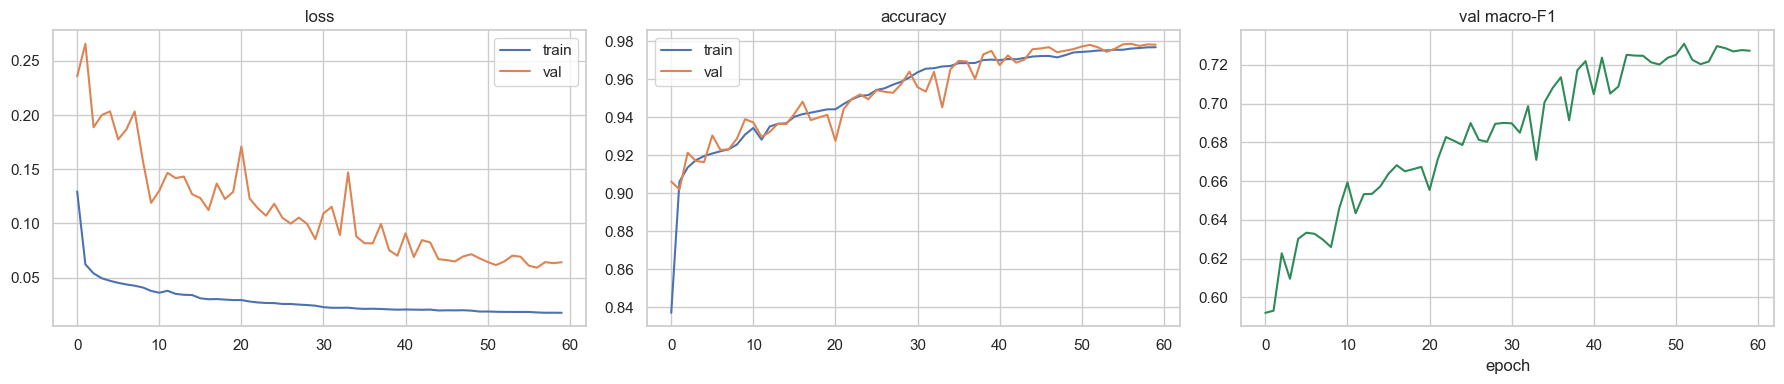

In [8]:
h = history.history
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(h["loss"], label="train"); axes[0].plot(h["val_loss"], label="val")
axes[0].set_title("loss"); axes[0].legend()
axes[1].plot(h["accuracy"], label="train"); axes[1].plot(h["val_accuracy"], label="val")
axes[1].set_title("accuracy"); axes[1].legend()
axes[2].plot(f1_cb.history, color="seagreen")
axes[2].set_title("val macro-F1"); axes[2].set_xlabel("epoch")
plt.tight_layout(); plt.show()


## 8. Validation report (per-class & macro)

In [9]:
y_pred = model.predict(X_val, batch_size=4096, verbose=0).argmax(axis=1)

all_labels = list(range(len(class_names)))   # tolerate classes absent from y_val/y_pred

print(f"Macro F1   : {f1_score(y_val, y_pred, labels=all_labels, average='macro',    zero_division=0):.4f}")
print(f"Weighted F1: {f1_score(y_val, y_pred, labels=all_labels, average='weighted', zero_division=0):.4f}\n")
print(classification_report(y_val, y_pred,
                            labels=all_labels,
                            target_names=class_names,
                            digits=4, zero_division=0))


Macro F1   : 0.7309
Weighted F1: 0.9826

                          precision    recall  f1-score   support

                  BENIGN     0.9999    0.9734    0.9865    340698
                     Bot     0.0920    0.9728    0.1681       294
                    DDoS     0.9951    0.9996    0.9973     19204
           DoS GoldenEye     0.8316    0.9981    0.9073      1544
                DoS Hulk     0.9162    0.9991    0.9559     34518
        DoS Slowhttptest     0.8460    0.9855    0.9104       825
           DoS slowloris     0.9589    0.9931    0.9757       870
             FTP-Patator     0.9302    0.9966    0.9623      1190
                PortScan     0.9911    0.9995    0.9953     23820
             SSH-Patator     0.4927    0.9966    0.6594       884
Web Attack  Brute Force     0.1331    0.9690    0.2341       226
        Web Attack  XSS     0.0833    0.0102    0.0182        98

                accuracy                         0.9782    424171
               macro avg     0.68

## 9. Confusion matrix

d:\smart_ids\ids_pfa\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.draw()
d:\smart_ids\ids_pfa\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


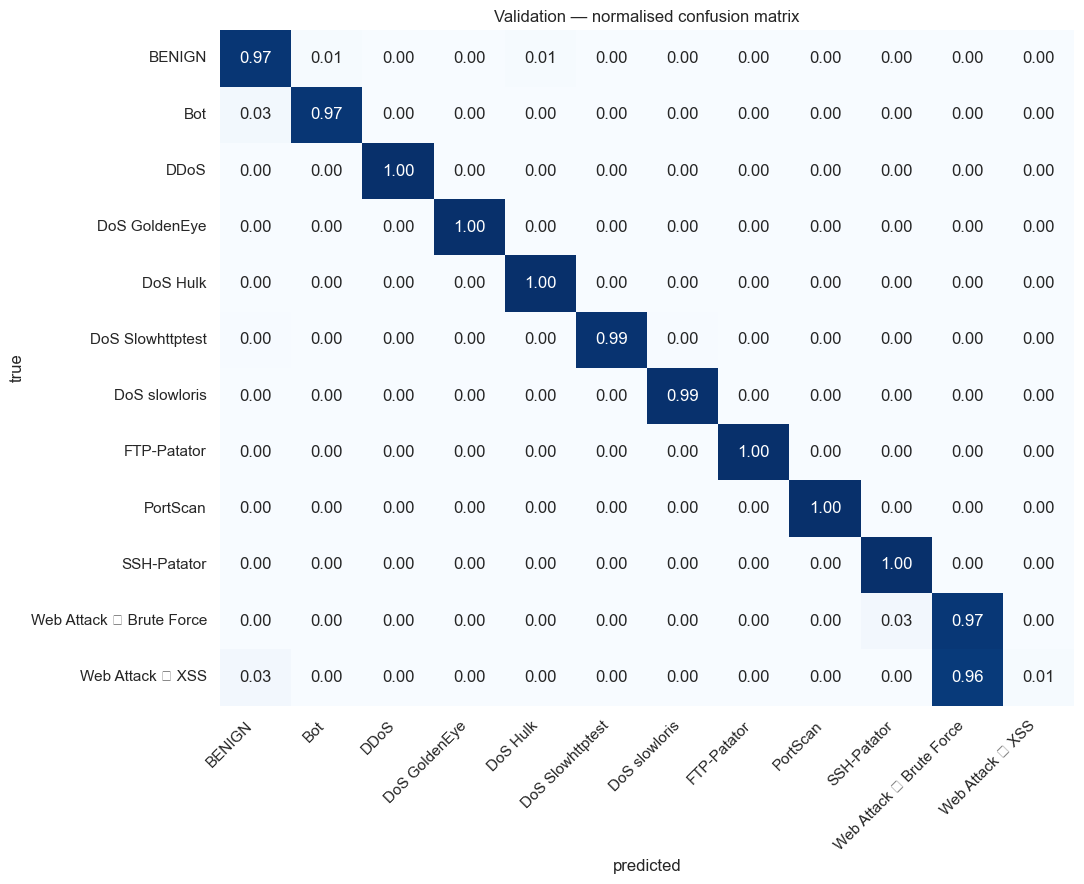

In [10]:
cm = confusion_matrix(y_val, y_pred, labels=all_labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

plt.figure(figsize=(11, 9))
sns.heatmap(cm_norm, xticklabels=class_names, yticklabels=class_names,
            annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.xlabel("predicted"); plt.ylabel("true")
plt.title("Validation — normalised confusion matrix")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


## 10. Persist the best model

In [11]:
# ModelCheckpoint already wrote the best epoch; re-save in canonical location
# (in case the in-memory `model` differs from the checkpoint).
model.save(cfg.MLP_MODEL_FILE)
print("Saved MLP ->", cfg.MLP_MODEL_FILE)


Saved MLP -> D:\smart_ids\models\mlp_model.keras


---
**Next:** `03_autoencoder_training.ipynb` for the unsupervised anomaly net.
